In [1]:
pip install qiskit numpy matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2389/503090571.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



PHI+ BELL STATE

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

STATEVECTOR
----------------------------------------------------------------------
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

THEORETICAL PROBABILITIES
----------------------------------------------------------------------
00 : 0.5000
01 : 0.0000
10 : 0.0000
11 : 0.5000

1024-SHOT MEASUREMENT RESULTS
----------------------------------------------------------------------
00 : 515
01 : 0
10 : 0
11 : 509

CORRELATION CHECK
----------------------------------------------------------------------
00 occurrences : 515
11 occurrences : 509
01 occurrences : 0
10 occurrences : 0

RESULT : Only 00 and 11 occurred.
VERIFICATION : CORRECT


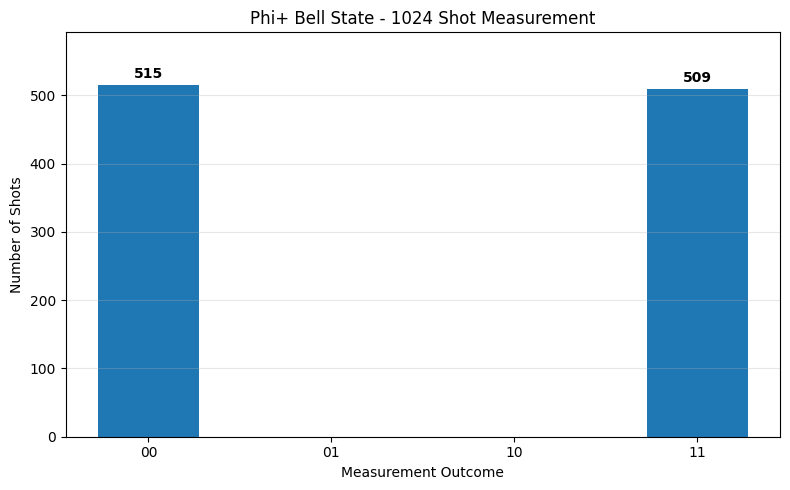

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

rng = np.random.default_rng(SEED)

outcomes = np.arange(4)

samples = rng.choice(
    outcomes,
    size=SHOTS,
    p=probabilities
)

counts = np.bincount(
    samples,
    minlength=4
)

labels = ["00", "01", "10", "11"]

print("\nPHI+ BELL STATE")
print("=" * 70)

print("\nQUANTUM CIRCUIT")
print("-" * 70)
print(qc.draw())

print("\nSTATEVECTOR")
print("-" * 70)
print(state)

print("\nTHEORETICAL PROBABILITIES")
print("-" * 70)

for label, probability in zip(labels, probabilities):
    print(f"{label} : {probability:.4f}")

print("\n1024-SHOT MEASUREMENT RESULTS")
print("-" * 70)

for label, count in zip(labels, counts):
    print(f"{label} : {count}")

print("\nCORRELATION CHECK")
print("-" * 70)

print(f"00 occurrences : {counts[0]}")
print(f"11 occurrences : {counts[3]}")
print(f"01 occurrences : {counts[1]}")
print(f"10 occurrences : {counts[2]}")

if counts[1] == 0 and counts[2] == 0:
    print("\nRESULT : Only 00 and 11 occurred.")
    print("VERIFICATION : CORRECT")
else:
    print("\nRESULT : Unexpected outcomes occurred.")
    print("VERIFICATION : INCORRECT")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    counts,
    width=0.55
)

ax.set_title(
    "Phi+ Bell State - 1024 Shot Measurement"
)

ax.set_xlabel(
    "Measurement Outcome"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_ylim(
    0,
    max(counts) * 1.15
)

for bar, value in zip(bars, counts):

    if value > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 10,
            str(value),
            ha="center",
            fontweight="bold"
        )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()